In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [6]:
from IPython.display import clear_output
from src.dataset_loaders import get_samplers_toy
from src.utils import get_pca_models
from src import utils
from src.train import train_toy
import wandb
from torch.utils.data import TensorDataset, DataLoader
import yaml
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt

## 1. Parameters.

Possible ```DATASET_NAME``` values are: ```twitter```, ```wiki-gigaword```, ```bone_marrow```

In [13]:
SOURCE_DIM   = 3  #38 (bone_marrow)
TARGET_DIM   = 2
MAX_ITERS    = 10000
DATASET_NAME = f'toy_{SOURCE_DIM}d_{TARGET_DIM}d'
METHOD_NAME  = 'FlowGW'
DEVICE       = 'cpu'
SEED         = 13
COST_DISCRETE= 'cosine'
N_CLUSTERS   = 10

config = {'dataset':dict(DATASET_NAME         = DATASET_NAME,
                         DEVICE               = DEVICE,
                         SOURCE_DIM           = SOURCE_DIM,
                         TARGET_DIM           = TARGET_DIM,
                         N_CLUSTERS           = N_CLUSTERS,
                         N_SAMPLES            = 1024,
                         SEED                 = SEED,
                         TRAIN_TYPE           = 'discrete',
                         NORMALIZE_VECS       = False
                          ),
          
          'training':dict(METHOD_NAME          = METHOD_NAME,
                          MAX_ITERS            = MAX_ITERS,
                          COST_DISCRETE        = COST_DISCRETE,
                          EPSILON              = 1e-3# AlignGW: 6e-4, FlowGW:1e-3, StructuredGW:
                          )}



## 2. Loading dataset.

torch.Size([1024, 3])
torch.Size([1024, 2])


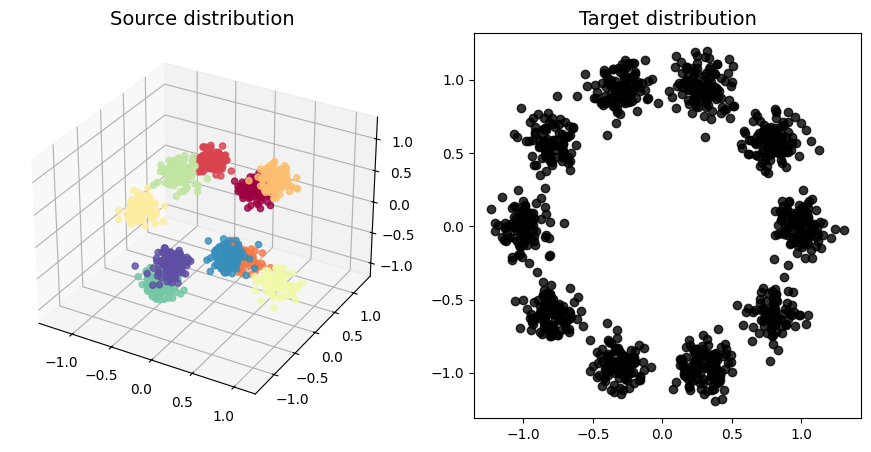

In [14]:

train_sampler = get_samplers_toy(config)
source_vectors, target_vectors, labels = train_sampler.sample(1024)

print(source_vectors.shape)
print(target_vectors.shape)

figure = plt.figure(figsize=(11,5))

if DATASET_NAME == 'toy_3d_2d':
    ax1 = figure.add_subplot(1, 2, 1, projection='3d')
    ax2 = figure.add_subplot(1, 2, 2, projection=None)
    
if DATASET_NAME == 'toy_2d_3d':
    ax1 = figure.add_subplot(1, 2, 1, projection=None)
    ax2 = figure.add_subplot(1, 2, 2, projection='3d')

ax1.scatter(*source_vectors.cpu().T, c=labels.cpu().numpy(), cmap="Spectral", alpha=.8)
ax1.set_title('Source distribution', fontsize=14)
ax2.scatter(*target_vectors.cpu().T, c='black', alpha=.8)
ax2.set_title('Target distribution', fontsize=14)

plt.show()

## 3. Training.

  0%|          | 0/10000 [00:00<?, ?it/s]

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


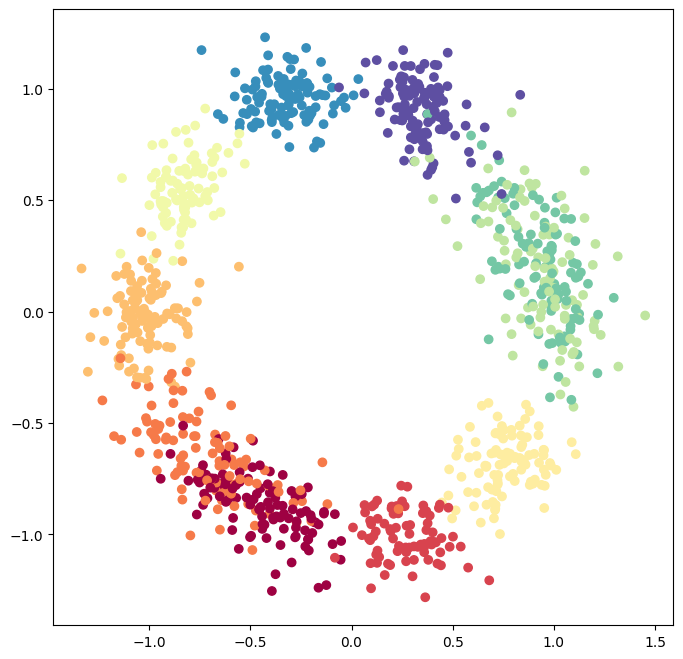

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


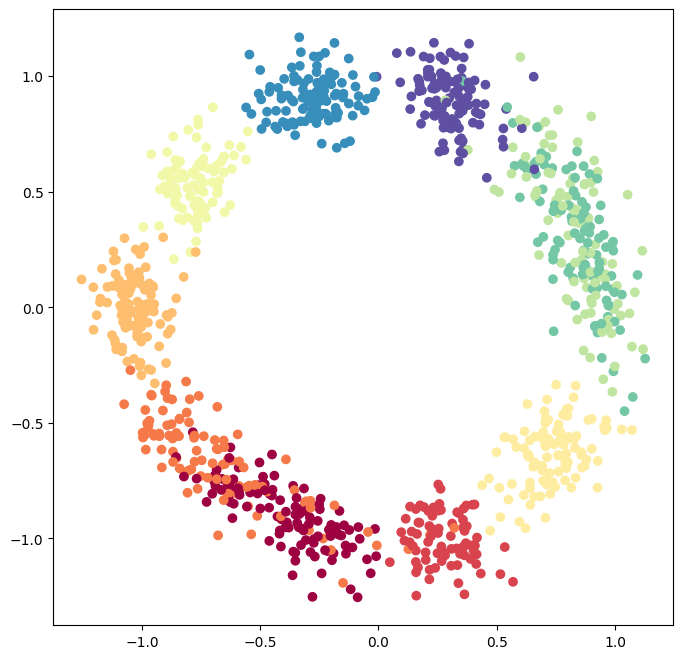

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


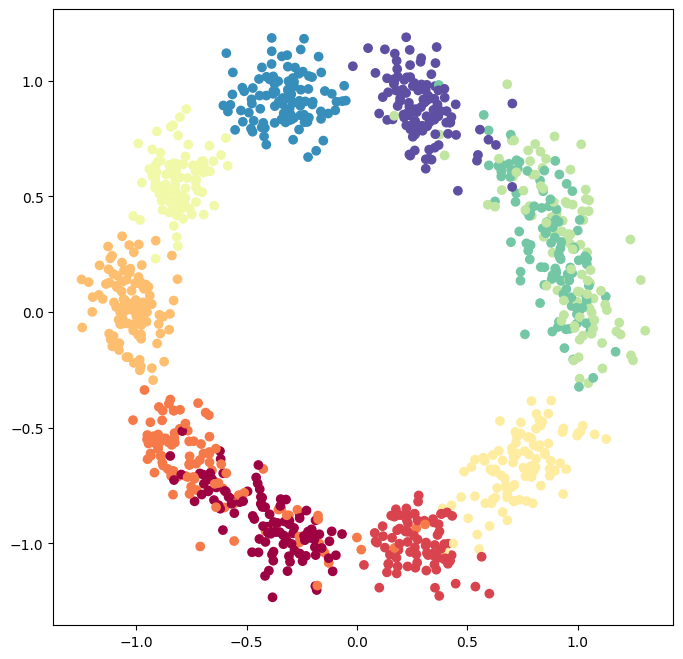

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


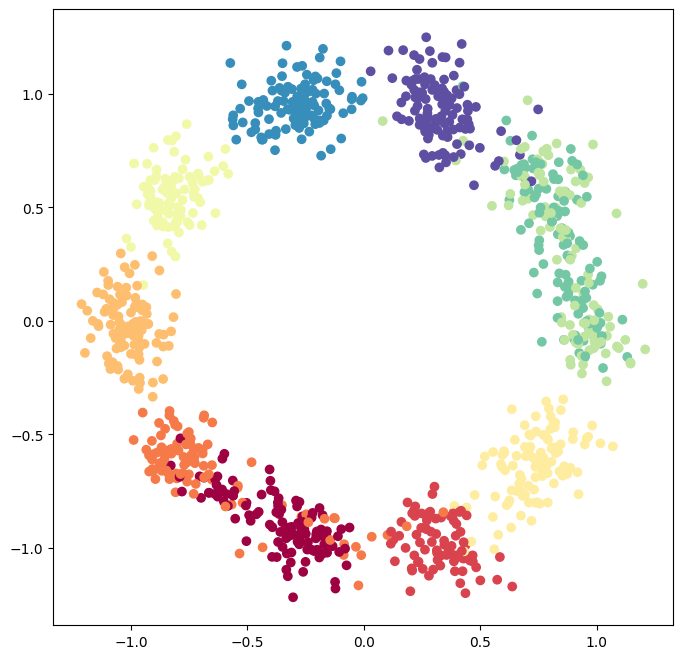

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


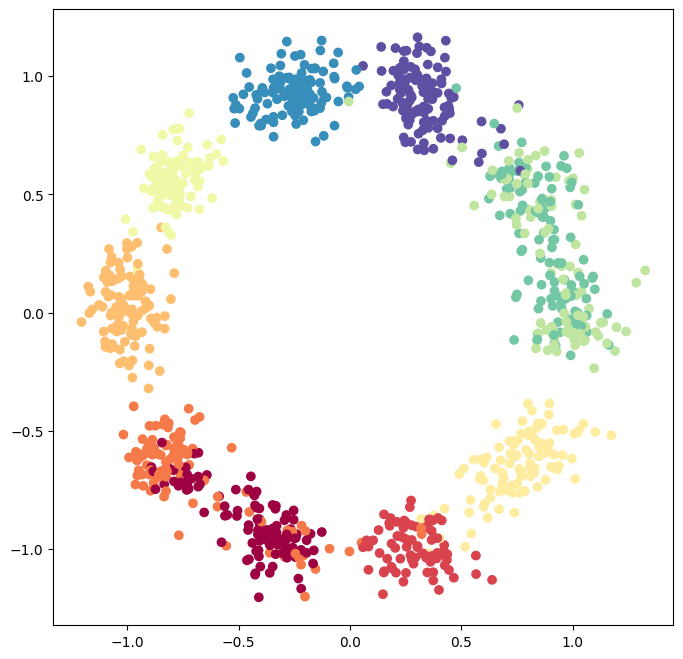

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


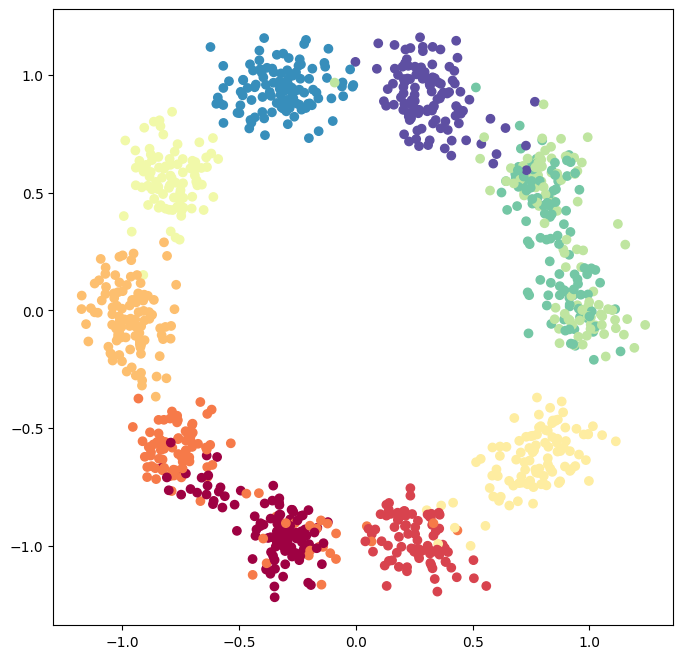

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


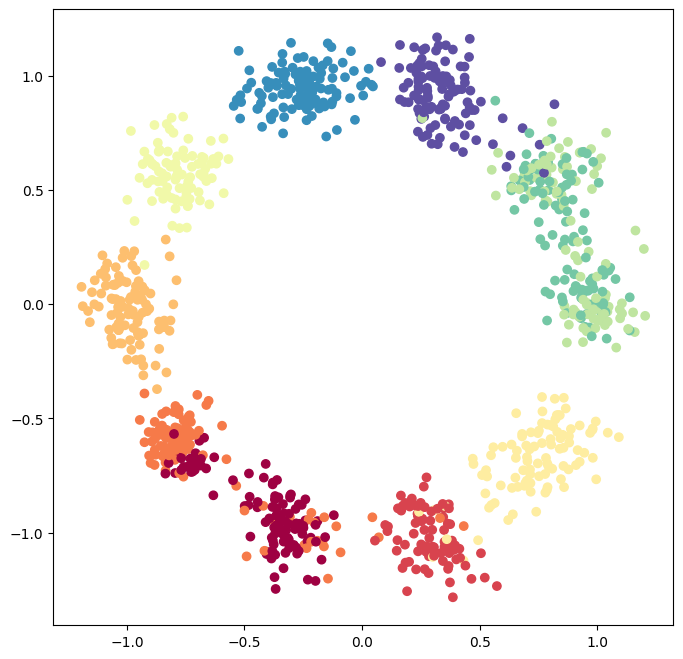

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


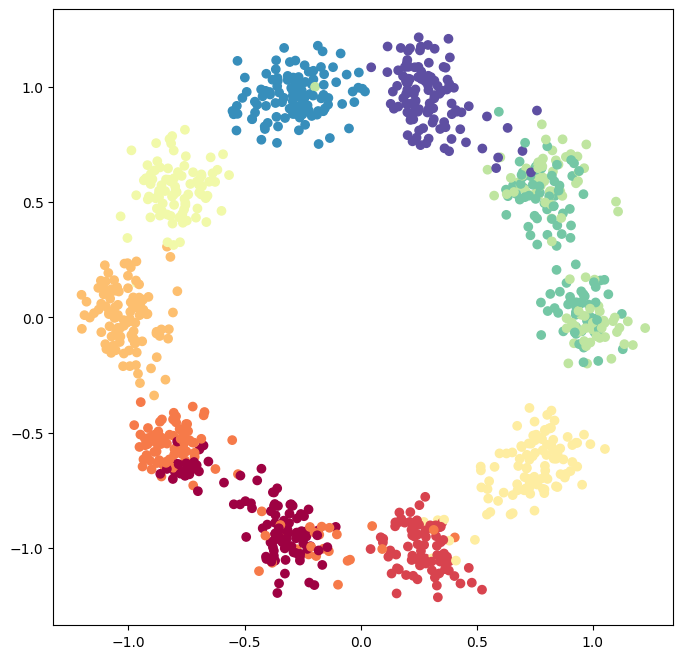

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


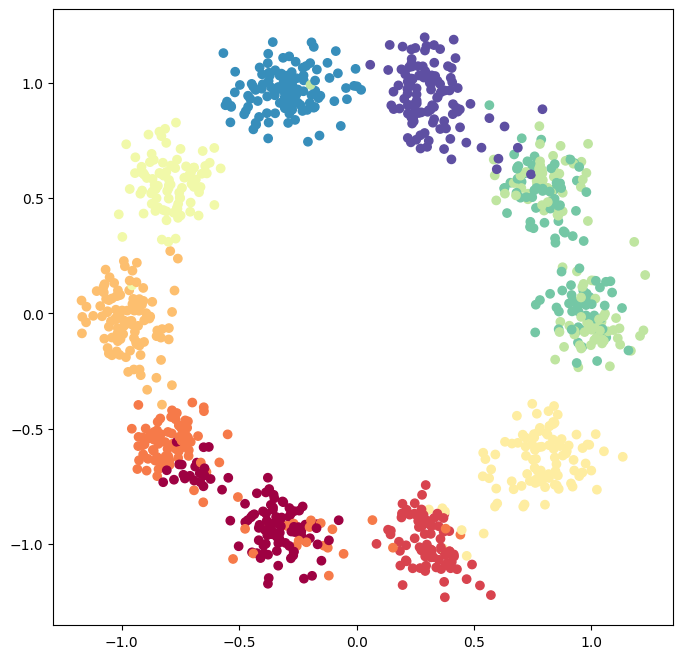

/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


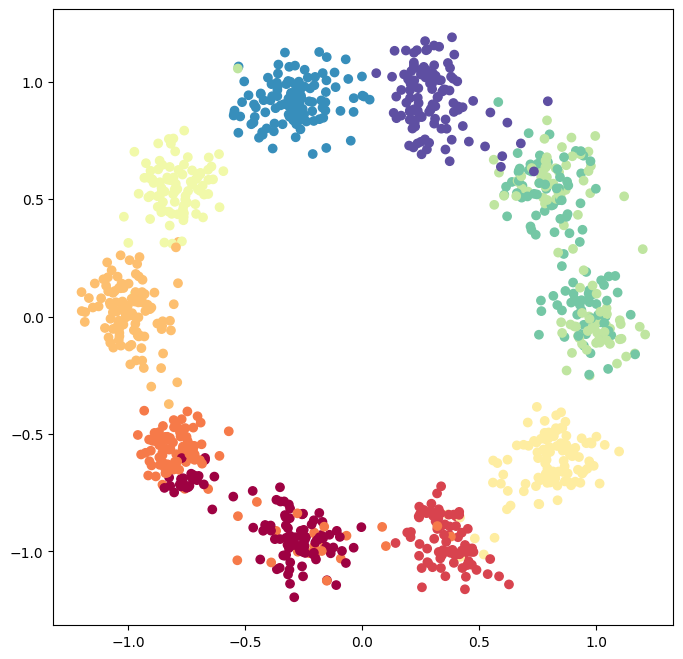

Interrumpting by keyboard...


In [15]:
trained_class = train_toy(train_sampler, 
                          config, axis_lims=None, 
                          report_every=200)